# FXトレーディング演習 — シナリオ設計レビュー

**運営チーム向け資料。参加者には配布しません。**

参加者向けチュートリアル [`day1-tutorial.ipynb`](./day1-tutorial.ipynb) で使う3つのシナリオ
（**各 1,000 tick**）について、

- どういう生成ルールのマーケットか（**参加者に見せる文面そのまま**）
- データの見え方
- 想定しているアルゴリズムと、その収益
- 合格ラインと、その設定根拠
- **他のアルゴリズムではどうやっても届かないこと**（参加者には見せません）

をシナリオごとにまとめます。

## この演習の骨子

参加者には**戦略を教えません**。データの生成ルールだけを与え、
「どういう性質のマーケットか」を読み取って**自力で戦略を思いつく**ことを狙っています。

したがって合格ラインは次を満たす必要があります。

> **意図した「考え方」に到達した場合にのみ超えられ、
> 別の考え方ではパラメータをどう振っても超えられない。**

本資料はこの性質を、パラメータ総当たりによって定量的に検証したものです。

## 目次

| 節 | 内容 |
|---|---|
| 1 | セットアップ（生成器・シミュレータ・3戦略） |
| 2 | シナリオ1 — ゆっくり育つマーケット |
| 3 | シナリオ2 — 引き戻されるマーケット |
| 4 | シナリオ3 — トレンドが続くマーケット |
| 5 | 全体サマリ |
| 6 | 運営向け補足（運用上の注意・所要時間） |

---
# 1. セットアップ

`day1-tutorial.ipynb` と**同一の**生成器・シミュレータ・戦略実装を使います。
数値が参加者側と食い違わないよう、ロジックはコピーではなく同じものを載せています。

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

INITIAL_JPY = 1_000_000.0
N_TICKS      = 1000   # 1シナリオの長さ（全シナリオ共通）
SAMPLE_TICKS = N_TICKS  # 系列が短いので、参加者にも全期間をそのまま見せる

# ---- 日本語フォント ----
_AVAIL = {f.name for f in fm.fontManager.ttflist}
_JP = next((f for f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "Noto Sans CJK JP",
                        "Noto Sans JP", "IPAexGothic", "TakaoPGothic", "MS Gothic",
                        "Arial Unicode MS"] if f in _AVAIL), None)
if _JP:
    plt.rcParams["font.family"] = [_JP, "DejaVu Sans"]

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # Buy&Hold / 逆張り / ゴールデンクロス で固定
INK, MUTED = "#0b0b0b", "#52514e"
GOOD, BAD = "#1baf7a", "#e34948"

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.unicode_minus": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "legend.frameon": False,
})
print("setup ok" + (f" / font={_JP}" if _JP else " / 日本語フォントなし"))

setup ok / font=Hiragino Sans


In [8]:
# =========================== データ生成器 ===========================
def generate_scenario1(n_ticks=1000, start_price=150.0, up_prob=0.61,
                       up_mean=0.0086, down_mean=0.0032, noise_std=0.09, seed=42):
    rng = np.random.RandomState(seed)
    p = np.zeros(n_ticks); p[0] = start_price
    for t in range(1, n_ticks):
        d = (abs(rng.normal(up_mean, noise_std)) if rng.rand() < up_prob
             else -abs(rng.normal(down_mean, noise_std)))
        p[t] = p[t - 1] + d
    return np.round(p, 3)


def generate_scenario2(n_ticks=1000, start_price=150.0, mean_price=150.0,
                       theta=0.1, sigma=1.1, seed=42):
    rng = np.random.RandomState(seed)
    p = np.zeros(n_ticks); p[0] = start_price
    for t in range(1, n_ticks):
        p[t] = p[t - 1] + theta * (mean_price - p[t - 1]) + sigma * rng.normal()
    return np.round(p, 3)


def generate_scenario3(n_ticks=1000, start_price=150.0, extra_length_avg=10,
                       min_regime_length=40, drift_strength=0.06, volatility=0.24,
                       seed=42, return_regime=False):
    """参加者向けと同じ生成器。運営用に隠れ状態 R_t も返せるようにしてある。"""
    rng = np.random.RandomState(seed)
    p = np.zeros(n_ticks); p[0] = start_price
    regimes = np.zeros(n_ticks, dtype=int); regimes[0] = 1
    regime, run_len, p_switch = 1, 0, 1.0 / extra_length_avg
    wasted = 0                      # 当選したが最短長に満たず破棄された回数
    for t in range(1, n_ticks):
        hit = rng.rand() < p_switch          # ← 抽選は毎 tick 必ず行われる
        if hit and run_len > min_regime_length:
            regime *= -1; run_len = 0
        else:
            if hit:
                wasted += 1                  # ← 当選しても繰り越されず捨てられる
            run_len += 1
        p[t] = p[t - 1] + regime * drift_strength + volatility * rng.normal()
        regimes[t] = regime
    p = np.round(p, 3)
    return (p, regimes, wasted) if return_regime else p

In [9]:
# =========================== シミュレータ（API と同じ契約） ===========================
def to_exchange_requests(target_ratio, balances, rates, base="USD", quote="JPY", eps=1e-9):
    target_ratio = min(1.0, max(0.0, float(target_ratio)))
    px = rates[f"{base}/{quote}"]
    base_amt, quote_amt = float(balances.get(base, 0.0)), float(balances.get(quote, 0.0))
    equity = quote_amt + base_amt * px
    diff = equity * target_ratio - base_amt * px
    if diff > eps:
        return [{"currencyFrom": quote, "currencyTo": base, "amount": diff}]
    if diff < -eps:
        return [{"currencyFrom": base, "currencyTo": quote, "amount": -diff / px}]
    return []


class LocalFxSimulator:
    """ショート不可・手数料0・USD/JPY のみ（本番APIと同じ制約）。"""
    def __init__(self, prices, initial_jpy=INITIAL_JPY):
        self.prices = np.asarray(prices, dtype=float)
        self.initial_jpy = float(initial_jpy)
        self.t, self.balances = 0, {}

    def _rates(self):
        px = float(self.prices[self.t]); return {"USD/JPY": px, "JPY/USD": 1.0 / px}

    def _state(self):
        r = self._rates()
        return {"tick": self.t, "complete": self.t >= len(self.prices) - 1,
                "currencyToBalance": dict(self.balances), "currentDateRates": r,
                "jpyBalance": self.balances["JPY"] + self.balances["USD"] * r["USD/JPY"]}

    def start(self):
        self.t = 0; self.balances = {"JPY": self.initial_jpy, "USD": 0.0}
        return self._state()

    def next(self, exchange_requests):
        rates = self._rates()
        for req in exchange_requests:
            src, dst = req["currencyFrom"], req["currencyTo"]
            amt = min(max(0.0, float(req["amount"])), self.balances.get(src, 0.0))
            self.balances[src] = self.balances.get(src, 0.0) - amt
            self.balances[dst] = self.balances.get(dst, 0.0) + amt * rates[f"{src}/{dst}"]
        self.t += 1
        return self._state()


class _Growable:
    def __init__(self, cap=1024):
        self._a = np.empty(cap, dtype=float); self._n = 0
    def append(self, v):
        if self._n == self._a.shape[0]:
            self._a = np.resize(self._a, self._a.shape[0] * 2)
        self._a[self._n] = v; self._n += 1
    def view(self):
        return self._a[:self._n]


def evaluate(strategy, prices, initial_jpy=INITIAL_JPY):
    sim = LocalFxSimulator(prices, initial_jpy)
    state = sim.start()
    buf, equity = _Growable(), _Growable()
    while True:
        buf.append(state["currentDateRates"]["USD/JPY"])
        equity.append(state["jpyBalance"])
        if state["complete"]:
            break
        target = strategy.decide(buf.view().shape[0] - 1, buf.view())
        state = sim.next(to_exchange_requests(target, state["currencyToBalance"],
                                              state["currentDateRates"]))
    eq = equity.view().copy()
    peak = np.maximum.accumulate(eq)
    return {"name": strategy.name, "final": float(eq[-1]),
            "return_pct": float((eq[-1] - initial_jpy) / initial_jpy * 100.0),
            "max_drawdown_pct": float(((eq - peak) / peak).min() * 100.0),
            "equity": eq}

In [10]:
# =========================== 3つの戦略（参加者の想定解） ===========================
class Strategy:
    name = "(no name)"
    def decide(self, t, prices): raise NotImplementedError


class BuyAndHold(Strategy):
    """シナリオ1の想定解。常にフルロング。"""
    name = "Buy & Hold"
    def decide(self, t, prices):
        return 1.0


class MeanReversion(Strategy):
    """シナリオ2の想定解。ボリンジャーバンドで「離れすぎ」を判定する逆張り。"""
    def __init__(self, window=20, num_std=2.0):
        self.window, self.num_std = window, num_std
        self.name = f"逆張り ({window}, {num_std})"
    def decide(self, t, prices):
        if len(prices) < self.window:
            return 0.0                        # 履歴が足りないうちは何もしない
        w = prices[-self.window:]
        mean, std = w.mean(), w.std(ddof=1)   # 移動平均=μの推定、移動標準偏差=ものさし
        if std == 0:
            return 0.0
        z = (prices[-1] - mean) / std         # いま何σ離れているか
        if z < -self.num_std:
            return 1.0                        # 安すぎる -> 全額 USD
        if z > self.num_std:
            return 0.0                        # 高すぎる -> 全額 JPY（ショート不可）
        return 0.0


class GoldenCross(Strategy):
    """シナリオ3の想定解。2本の移動平均の位置関係でレジームを推定するゴールデンクロス。"""
    def __init__(self, short_window=5, long_window=20):
        self.short_window, self.long_window = short_window, long_window
        self.name = f"ゴールデンクロス ({short_window}, {long_window})"
    def decide(self, t, prices):
        if len(prices) < self.long_window:
            return 0.0                        # 長期線が引けるまで待つ
        short_ma = prices[-self.short_window:].mean()
        long_ma  = prices[-self.long_window:].mean()
        return 1.0 if short_ma > long_ma else 0.0

In [11]:
# =========================== シナリオ定義 & 描画ヘルパ ===========================
_p3, REGIME3, WASTED3 = generate_scenario3(return_regime=True)
PRICES = {1: generate_scenario1(), 2: generate_scenario2(), 3: _p3}
TITLE = {1: "ゆっくり育つマーケット", 2: "引き戻されるマーケット", 3: "トレンドが続くマーケット"}
NATURE = {1: "上に偏ったランダムウォーク", 2: "平均回帰 (Ornstein-Uhlenbeck)",
          3: "レジームスイッチング"}
THRESHOLD = {1: 7.0, 2: 5.0, 3: 5.0}
INTENDED = {1: "Buy & Hold", 2: "逆張り (Bollinger)", 3: "ゴールデンクロス"}

# パラメータ総当たりの格子
# 窓幅 w の中で1点が取りうる |z| の上限は (w-1)/sqrt(w)。
# これを超える num_std は「構造的に絶対発火しない」ので、集計から除外する。
_WS, _KS = [5, 10, 20, 30, 60, 120], [1.0, 1.5, 2.0, 2.5, 3.0]
def z_ceiling(w):
    return (w - 1) / np.sqrt(w)
MR_GRID     = [(w, k) for w in _WS for k in _KS if k <  z_ceiling(w)]
MR_INFEASIBLE = [(w, k) for w in _WS for k in _KS if k >= z_ceiling(w)]
GC_GRID = [(s, l) for s in [3, 5, 10, 20, 50]
           for l in [15, 20, 30, 60, 100, 200] if s < l]

FAMILY = {
    "Buy & Hold":            [BuyAndHold()],
    "逆張り (Bollinger)":     [MeanReversion(w, k) for w, k in MR_GRID],
    "ゴールデンクロス":  [GoldenCross(s, l) for s, l in GC_GRID],
}


def price_plot(prices, title, color=SERIES[0], hline=None, xlabel="tick"):
    fig, ax = plt.subplots()
    ax.plot(prices, lw=1.2, color=color)
    if hline is not None:
        ax.axhline(hline, lw=1.0, ls="--", color=MUTED, alpha=0.7)
        ax.text(len(prices) * 0.995, hline, f"{hline:g}", va="bottom", ha="right",
                fontsize=9, color=MUTED,
                bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("USD/JPY")
    ax.grid(True, axis="y"); ax.margins(x=0.01)
    plt.tight_layout(); plt.show()


def _place_labels(ax, items, gap_frac=0.055):
    """終端ラベルが重ならないよう縦位置をずらす。items=[(y, text, color)]"""
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * gap_frac
    items = sorted(items, key=lambda it: it[0])
    ys = [it[0] for it in items]
    for i in range(1, len(ys)):
        if ys[i] - ys[i - 1] < gap:
            ys[i] = ys[i - 1] + gap
    return [(ys[i], items[i][1], items[i][2]) for i in range(len(items))]


def equity_plot(n, results, title=None):
    """1シナリオ上での複数戦略の資産推移を重ねる。results=[(label, res, color)]"""
    th = THRESHOLD[n]
    fig, ax = plt.subplots(figsize=(11, 4.8))
    items = []
    for label, res, color in results:
        eq = (res["equity"] / INITIAL_JPY - 1.0) * 100.0
        ax.plot(eq, lw=1.8, color=color, label=label)
        items.append((eq[-1], f"{label}  {res['return_pct']:+.2f}%", color))
    ax.axhline(0, lw=1.0, color=MUTED, alpha=0.5)
    ax.axhline(th, lw=1.3, ls="--", color=MUTED)
    ax.text(0, th, f" 合格ライン {th:g}%", va="bottom", ha="left", fontsize=9, color=MUTED)
    xmax = max(len(r["equity"]) for _, r, _ in results)
    ax.set_xlim(0, xmax * 1.30)          # 右に直接ラベル用の余白
    for y, text, color in _place_labels(ax, items):
        ax.text(xmax * 1.02, y, text, va="center", ha="left",
                fontsize=10, fontweight="bold", color=color)
    ax.set_title(title or f"シナリオ{n} 上での資産推移の比較")
    ax.set_xlabel("tick"); ax.set_ylabel("損益 (%)")
    ax.grid(True, axis="y")
    ax.legend(loc="upper left", ncol=3, fontsize=9)
    plt.tight_layout(); plt.show()


def family_table(n):
    """各戦略ファミリーを総当たりし、合格ライン超えの有無を集計する。"""
    th, prices = THRESHOLD[n], PRICES[n]
    rows = []
    for fam, strategies in FAMILY.items():
        rets = [evaluate(s, prices)["return_pct"] for s in strategies]
        best_i = int(np.argmax(rets))
        rows.append({
            "戦略ファミリー": fam,
            "試したパラメータ数": len(rets),
            "最良 [%]": round(max(rets), 3),
            "中央値 [%]": round(float(np.median(rets)), 3),
            "最悪 [%]": round(min(rets), 3),
            "最良パラメータ": strategies[best_i].name,
            f"合格ライン({th}%)超え": f"{sum(r >= th for r in rets)}/{len(rets)}",
        })
    return pd.DataFrame(rows).set_index("戦略ファミリー")

def regime_plot(prices, regimes, title, n=None, mas=None):
    """価格に隠れ状態レジームを背景色で重ねる（運営用）。"""
    n = n or len(prices)
    px, rg = prices[:n], regimes[:n]
    fig, ax = plt.subplots(figsize=(11, 4.6))

    edges = np.flatnonzero(np.diff(rg)) + 1          # レジームが切り替わる位置
    for a, b in zip(np.r_[0, edges], np.r_[edges, n]):
        ax.axvspan(a, b, color=SERIES[0] if rg[a] > 0 else SERIES[1], alpha=0.10, lw=0)

    ax.plot(px, lw=1.0, color=INK if mas else SERIES[2],
            alpha=0.55 if mas else 1.0, label="価格", zorder=3)
    if mas:
        ser = pd.Series(px)
        for w, color, label in mas:
            ax.plot(ser.rolling(w).mean(), lw=1.9, color=color, label=label, zorder=4)

    from matplotlib.patches import Patch
    handles, _ = ax.get_legend_handles_labels()
    handles += [Patch(facecolor=SERIES[0], alpha=0.10, label="上昇レジーム R=+1"),
                Patch(facecolor=SERIES[1], alpha=0.10, label="下降レジーム R=−1")]
    # データ線と重なっても読めるよう、凡例には白い下敷きを付ける
    leg = ax.legend(handles=handles, loc="upper left", ncol=2, fontsize=9,
                    frameon=True, framealpha=0.92, edgecolor="none")
    leg.get_frame().set_facecolor("white")
    ax.set_title(title); ax.set_xlabel("tick"); ax.set_ylabel("USD/JPY")
    ax.grid(True, axis="y"); ax.margins(x=0.01)
    plt.tight_layout(); plt.show()


# 各シナリオの評価結果はシナリオ節で埋め、最後の全体サマリで再利用する
BASE = [("Buy & Hold", BuyAndHold(), SERIES[0]),
        ("逆張り (20, 2.0)", MeanReversion(20, 2.0), SERIES[1]),
        ("ゴールデンクロス (5, 20)", GoldenCross(5, 20), SERIES[2])]
RESULTS, TABLES = {}, {}

print("ready — 3シナリオ生成済み")

ready — 3シナリオ生成済み


---
# 2. シナリオ1 — ゆっくり育つマーケット

## 2.1 参加者に見せる生成ルール

> 以下は **参加者向けの文面そのまま**です。

初期価格を

$$P_0 = 150$$

とし、時刻 $t$ の価格 $P_t$ を次の漸化式で生成します。

$$P_t = P_{t-1} + \Delta P_t$$

価格変化量 $\Delta P_t$ は、各ステップで独立に次のルールで決まります。

$$
\Delta P_t =
\begin{cases}
\ \ \left| \mathcal{N}(0.0086,\ 0.09^2) \right| & \text{確率 } 0.61 \\[4pt]
-\left| \mathcal{N}(0.0032,\ 0.09^2) \right| & \text{確率 } 0.39
\end{cases}
$$

**このルールから読み取れること（参加者向け）**

- 各ステップで 61% の確率で上昇、39% の確率で下落します。
- 上昇時の平均変化量 (0.0086) は、下落時の平均変化量 (0.0032) より大きいです。
- 次の価格は「直前の価格」と「新しい乱数」だけで決まります。
- **過去の値動きは、次の変化の向きに一切影響しません。**

始値 150.000 → 終値 161.377   (最安 150.000 / 最高 161.377)

1ステップあたりの期待変化量:
  E[|N(0.0086, 0.09^2)|] = 0.072137   (0.0086 ではない点に注意)
  E[|N(0.0032, 0.09^2)|] = 0.071855
  理論値 E[dP]            = +0.015980   -> x1000 = +15.98 円
  実測 (この系列)          = +0.011388   -> 実際 +11.38 円
  [誤り] 0.61*0.0086-0.39*0.0032 = +0.003998  <- 絶対値を無視した式
  モンテカルロ(2,000,000回)   = +0.015926 ± 0.000123 (95%CI)   -> 理論値はCI内


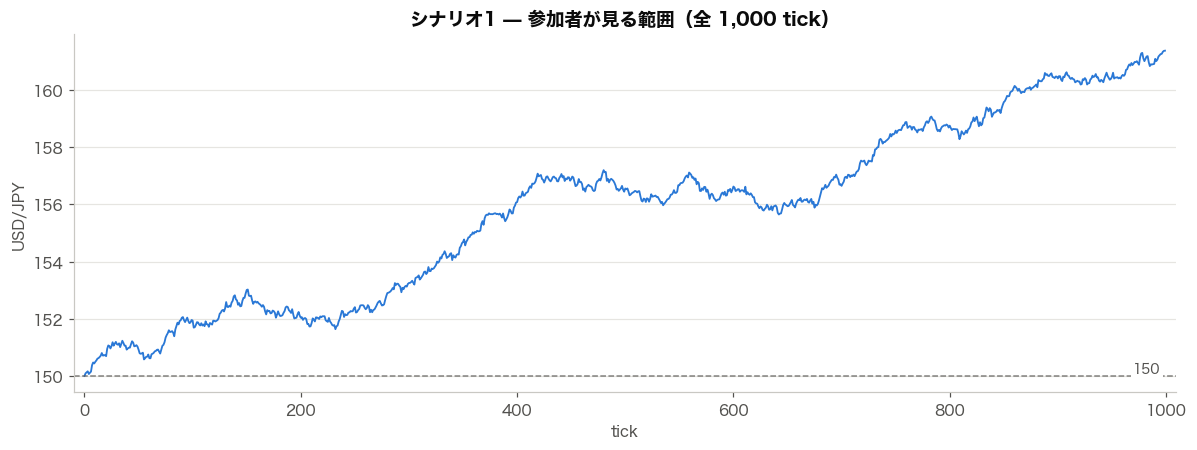

In [12]:
from math import sqrt, pi, exp, erf

def _folded_mean(mu, s):
    """E[|N(mu, s^2)|] （折り返し正規分布の平均）"""
    Phi = lambda x: 0.5 * (1 + erf(x / sqrt(2)))
    return s * sqrt(2 / pi) * exp(-mu * mu / (2 * s * s)) + mu * (1 - 2 * Phi(-mu / s))

_up, _dn = _folded_mean(0.0086, 0.09), _folded_mean(0.0032, 0.09)
_theory = 0.61 * _up - 0.39 * _dn

p = PRICES[1]
print(f"始値 {p[0]:.3f} → 終値 {p[-1]:.3f}   (最安 {p.min():.3f} / 最高 {p.max():.3f})")
print()
print("1ステップあたりの期待変化量:")
print(f"  E[|N(0.0086, 0.09^2)|] = {_up:.6f}   (0.0086 ではない点に注意)")
print(f"  E[|N(0.0032, 0.09^2)|] = {_dn:.6f}")
print(f"  理論値 E[dP]            = {_theory:+.6f}   -> x{N_TICKS} = {_theory*N_TICKS:+.2f} 円")
print(f"  実測 (この系列)          = {np.diff(p).mean():+.6f}   -> 実際 {p[-1]-p[0]:+.2f} 円")
print(f"  [誤り] 0.61*0.0086-0.39*0.0032 = {0.61*0.0086-0.39*0.0032:+.6f}  <- 絶対値を無視した式")

# モンテカルロ検証
_rng = np.random.RandomState(0); _N = 2_000_000
_d = np.where(_rng.rand(_N) < 0.61,
              np.abs(_rng.normal(0.0086, 0.09, _N)),
              -np.abs(_rng.normal(0.0032, 0.09, _N)))
_se = _d.std() / np.sqrt(_N)
print(f"  モンテカルロ({_N:,}回)   = {_d.mean():+.6f} ± {1.96*_se:.6f} (95%CI)"
      f"   -> 理論値は{'CI内' if abs(_d.mean()-_theory) < 1.96*_se else 'CI外'}")

price_plot(p, "シナリオ1 — 参加者が見る範囲（全 1,000 tick）",
           color=SERIES[0], hline=150.0)

## 2.3 想定アルゴリズムと収益

### 想定解のアルゴリズム

```python
class BuyAndHold(Strategy):
    """常にフルロング。"""
    name = "Buy & Hold"

    def decide(self, t, prices):
        return 1.0
```

増分が独立なのでタイミングを計る意味がなく、**何もしない**のが最適解です。

In [13]:
RESULTS[1] = {label: evaluate(s, PRICES[1]) for label, s, _ in BASE}

res = RESULTS[1]["Buy & Hold"]
print(f"想定解      : Buy & Hold   ->   def decide(self, t, prices): return 1.0")
print(f"リターン    : {res['return_pct']:+.3f} %   （合格ライン {THRESHOLD[1]} %）")
print(f"最終資産    : {res['final']:,.0f} JPY")
print(f"最大DD      : {res['max_drawdown_pct']:.3f} %")

想定解      : Buy & Hold   ->   def decide(self, t, prices): return 1.0
リターン    : +7.585 %   （合格ライン 7.0 %）
最終資産    : 1,075,847 JPY
最大DD      : -0.986 %


## 2.4 他のアルゴリズムでは届かない

**この節の内容は参加者には見せません。**

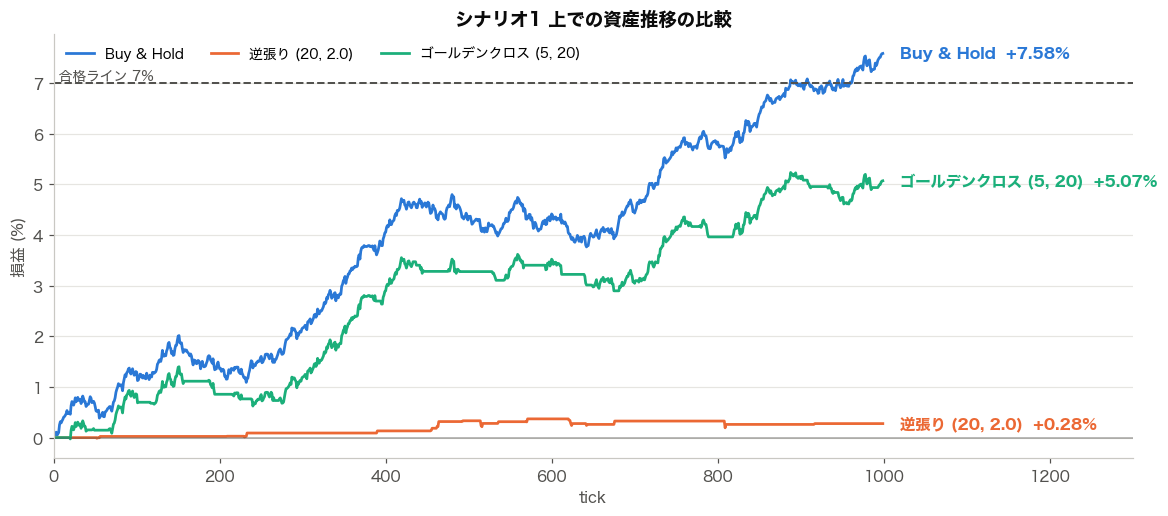

,試したパラメータ数,最良 [%],中央値 [%],最悪 [%],最良パラメータ,合格ライン(7.0%)超え
戦略ファミリー,,,,,,
Buy & Hold,1,7.585,7.585,7.585,Buy & Hold,1/1
逆張り (Bollinger),26,1.939,0.381,0.000,"逆張り (5, 1.0)",0/26
ゴールデンクロス,25,6.189,5.600,4.817,"ゴールデンクロス (10, 60)",0/25


In [14]:
TABLES[1] = family_table(1)

equity_plot(1, [(label, RESULTS[1][label], color) for label, _, color in BASE])
display(TABLES[1])

### 結論

- Buy & Hold の **+7.585 %** に対し、ゴールデンクロスは全25通りが **4.82 %〜6.19 %** に収まります
  （最良 `short=10, long=60` の **6.19 %**）。合格ライン **7.0 %** はこの隙間に置いてあります。
- 逆張りはほぼ機能しません（このデータには「戻る」性質が無いため。最良 **1.94 %**、中央値 0.38 %）。
- **売買を挟むほど上昇に乗れない時間が生まれ、成績が下がる**という構造になっています。
  「何かしたくなる」のを我慢できるかを問う設計です。

> **注意（1,000 tick 化で最も影響を受けた箇所）**
> 43,200 tick 版ではゴールデンクロスの最良が Buy & Hold の 62 % 止まりでしたが、
> 1,000 tick では **82 %** まで迫ります。ゴールデンクロスの負けは「往復の取りこぼしが
> 積み上がること」で生まれるため、tick 数が減ると差が詰まるためです。
> 結果として**このシナリオだけ合格ラインの余裕が薄く**（上下 0.6〜0.8 pt）、
> データを別 seed で作り直すと分離が壊れることがあります。**seed=42 固定が前提**です。

---
# 3. シナリオ2 — 引き戻されるマーケット

## 3.1 参加者に見せる生成ルール

> 以下は **参加者向けの文面そのまま**です。

初期価格と長期均衡価格を

$$P_0 = \mu = 150$$

とし、価格 $P_t$ を次の漸化式で生成します。

$$P_t = P_{t-1} + \underbrace{\theta\,(\mu - P_{t-1})}_{\text{第1項}} + \underbrace{\sigma\, \varepsilon_t}_{\text{第2項}}$$

$$\theta = 0.1, \qquad \sigma = 1.1, \qquad \varepsilon_t \sim \mathcal{N}(0, 1)$$

**このルールから読み取れること（参加者向け）**

- 第2項はただのランダムなノイズで、向きに偏りはありません。
- 第1項は $\mu = 150$ を基準に、安いとき上向き・高いとき下向きの力を生みます。
- その力は $\mu$ から離れているほど強くなります。
- シナリオ1と違い、**過去の位置が次の変化の向きに影響します。**

始値 150.000 → 終値 148.901   (最安 144.201 / 最高 157.982)
全期間の平均価格: 150.216  (μ=150 に一致)


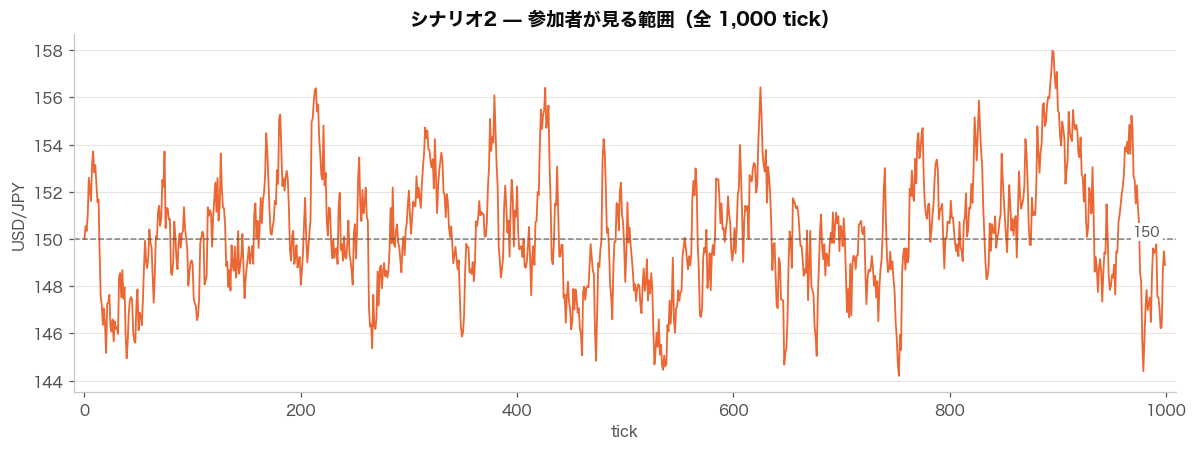

In [15]:
p = PRICES[2]
print(f"始値 {p[0]:.3f} → 終値 {p[-1]:.3f}   (最安 {p.min():.3f} / 最高 {p.max():.3f})")
print(f"全期間の平均価格: {p.mean():.3f}  (μ=150 に一致)")
price_plot(p, "シナリオ2 — 参加者が見る範囲（全 1,000 tick）",
           color=SERIES[1], hline=150.0)

## 3.3 想定アルゴリズムと収益

### 想定解のアルゴリズム

```python
class MeanReversion(Strategy):
    """ボリンジャーバンドで「離れすぎ」を判定する逆張り。"""

    def __init__(self, window=20, num_std=2.0):
        self.window, self.num_std = window, num_std

    def decide(self, t, prices):
        if len(prices) < self.window:
            return 0.0                        # 履歴が足りないうちは何もしない
        w = prices[-self.window:]
        mean, std = w.mean(), w.std(ddof=1)   # 移動平均=μの推定、移動標準偏差=ものさし
        if std == 0:
            return 0.0
        z = (prices[-1] - mean) / std         # いま何σ離れているか
        if z < -self.num_std:
            return 1.0                        # 安すぎる -> 全額 USD
        if z > self.num_std:
            return 0.0                        # 高すぎる -> 全額 JPY（ショート不可）
        return 0.0
```

μ を知らない前提でも、**移動平均が μ の推定値**に、**移動標準偏差が「離れ具合」のものさし**になります。

In [16]:
RESULTS[2] = {label: evaluate(s, PRICES[2]) for label, s, _ in BASE}

res = RESULTS[2]["逆張り (20, 2.0)"]
print("想定解      : 逆張り / ボリンジャーバンド (window=20, num_std=2.0)")
print(f"リターン    : {res['return_pct']:+.3f} %   （合格ライン {THRESHOLD[2]} %）")
print(f"最終資産    : {res['final']:,.0f} JPY")
print(f"最大DD      : {res['max_drawdown_pct']:.3f} %")

想定解      : 逆張り / ボリンジャーバンド (window=20, num_std=2.0)
リターン    : +8.549 %   （合格ライン 5.0 %）
最終資産    : 1,085,493 JPY
最大DD      : -2.796 %


## 3.4 他のアルゴリズムでは届かない

**この節の内容は参加者には見せません。**

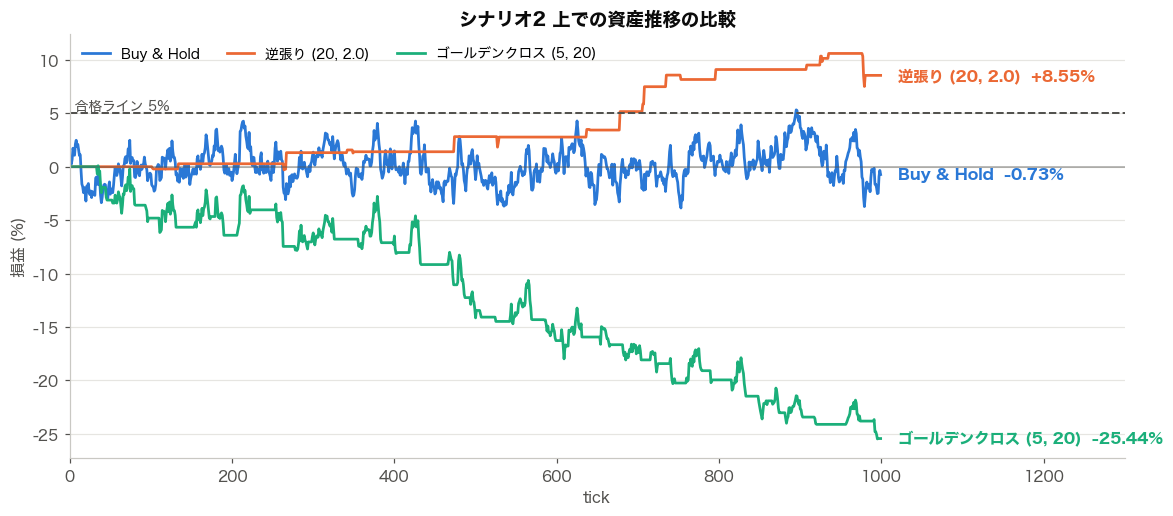

,試したパラメータ数,最良 [%],中央値 [%],最悪 [%],最良パラメータ,合格ライン(5.0%)超え
戦略ファミリー,,,,,,
Buy & Hold,1,-0.733,-0.733,-0.733,Buy & Hold,0/1
逆張り (Bollinger),26,48.252,10.355,-0.330,"逆張り (30, 1.0)",15/26
ゴールデンクロス,25,-8.954,-28.153,-38.127,"ゴールデンクロス (50, 60)",0/25


In [11]:
TABLES[2] = family_table(2)

equity_plot(2, [(label, RESULTS[2][label], color) for label, _, color in BASE])
display(TABLES[2])

### パラメータ感度（逆張りのみ）

合格ライン 5.0 % を「どのくらいのパラメータ範囲で超えられるか」を可視化します。

In [12]:
grid = pd.DataFrame(
    [[round(evaluate(MeanReversion(w, k), PRICES[2])["return_pct"], 2)
      if k < z_ceiling(w) else np.nan          # 発火不可能な組み合わせは除外
      for k in _KS] for w in _WS],
    index=[f"window={w}" for w in _WS],
    columns=[f"num_std={k}" for k in _KS],
)
th = THRESHOLD[2]
print(f"逆張りのリターン [%]（緑＝合格ライン {th}% 超え / — ＝構造的に発火不可能）\n")
try:
    display(grid.style.format("{:+.2f}", na_rep="—")
            .map(lambda v: "" if pd.isna(v) else
                 (f"color: {GOOD}; font-weight: bold" if v >= th else f"color: {BAD}"))
            .set_caption(f"シナリオ2 × 逆張り パラメータ感度（合格ライン {th}%）"))
except Exception:
    print(grid.to_string())

vals = grid.to_numpy()[~np.isnan(grid.to_numpy())]
print(f"\n通過: {int((vals >= th).sum())}/{len(vals)} 通り（実行可能な組み合わせのみ）")
print(f"発火不可能で除外: {len(MR_INFEASIBLE)} 通り {MR_INFEASIBLE}")

逆張りのリターン [%]（緑＝合格ライン 5.0% 超え / — ＝構造的に発火不可能）

            num_std=1.0  num_std=1.5  num_std=2.0  num_std=2.5  num_std=3.0
window=5          13.01         2.57          NaN          NaN          NaN
window=10         26.32        12.61        -0.33         0.00          NaN
window=20         47.53        23.57         8.55        -0.11          0.4
window=30         48.25        33.61        11.68         1.10          0.0
window=60         35.36        26.35         9.03         2.65          0.0
window=120        34.50        24.95        12.67         2.45          0.0

通過: 15/26 通り（実行可能な組み合わせのみ）
発火不可能で除外: 4 通り [(5, 2.0), (5, 2.5), (5, 3.0), (10, 3.0)]


### 結論

- 逆張りは **15/26 通り**で合格ラインを超えます。**考え方が合っていれば、
  パラメータが多少ズレていても通る**という設計です。
- 落ちるのはほぼ `num_std >= 2.5` の設定（バンドが広すぎてシグナルがほとんど出ない）です。
  想定解として提示する `window=20, num_std=2.0` は **8.55 %** で余裕をもって通過します。
- 一方 Buy & Hold は **−0.733 %**、ゴールデンクロスは全25通りが**マイナス**（最良 −8.95 %）。
  ゴールデンクロスがここまで負けるのは、往復する値動きに対して毎回出遅れて売買するためです。
- 合格ライン 5.0 % に対し想定解は 8.55 %、対抗ファミリーの最良は 0 % を割っており、
  **3シナリオ中もっとも分離が明確**です。

---
# 4. シナリオ3 — トレンドが続くマーケット

## 4.1 参加者に見せる生成ルール

> 以下は **参加者向けの文面そのまま**です。

このマーケットには **「レジーム（相場つき）」** という隠れ状態 $R_t \in \{+1, -1\}$ があります。

$$P_0 = 150$$

**レジームの遷移**（$L_t$ は現在のレジームが続いている長さ）:

$$
R_t =
\begin{cases}
-R_{t-1} & \text{確率 } p = \tfrac{1}{10} \ \text{ かつ } \ L_{t-1} > 40 \\[4pt]
\ \ R_{t-1} & \text{それ以外}
\end{cases}
$$

**価格の更新**:

$$P_t = P_{t-1} + \underbrace{R_t \cdot \kappa}_{\text{ドリフト}} + \underbrace{\sigma\,\varepsilon_t}_{\text{ノイズ}}$$

$$\kappa = 0.06, \qquad \sigma = 0.24$$

**このルールから読み取れること（参加者向け）**

- $R_t = +1$ の間は毎ステップ上向きのドリフトがかかり続けます。
- レジームは最低41ステップ、平均するとおよそ51ステップ続きます。**一度決まった向きはしばらく持続します。**
- ただし **$R_t$ は観測できません。** 見えるのは価格だけです。
- シナリオ2は「離れたら戻る」でしたが、こちらは **「動き出したらしばらく同じ向きに進む」** です。

始値 150.000 → 終値 151.579   (最安 149.031 / 最高 161.719)
※ 終値はほぼ始値どおり。それでもトレンドを乗り継げば利益が出る点に注意


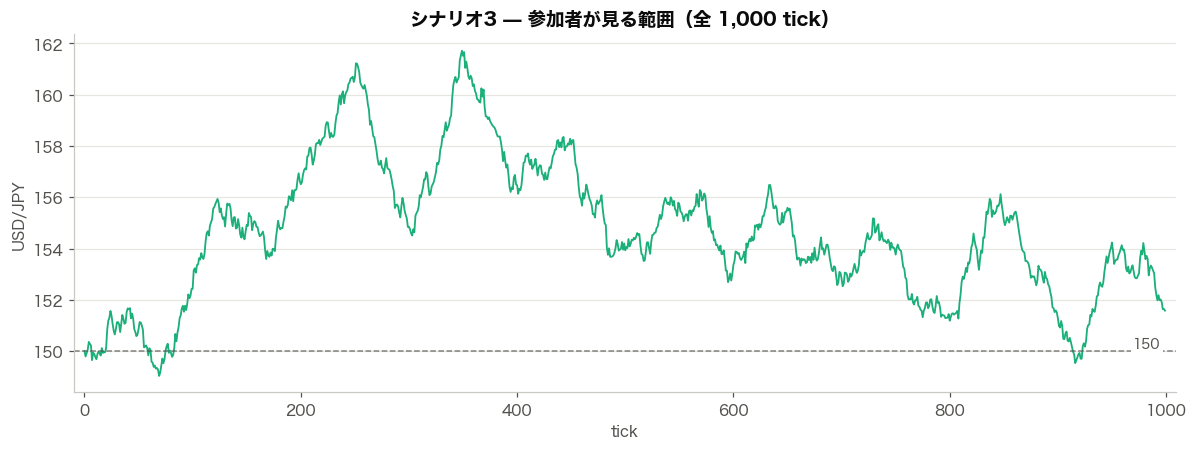

In [13]:
p = PRICES[3]
print(f"始値 {p[0]:.3f} → 終値 {p[-1]:.3f}   (最安 {p.min():.3f} / 最高 {p.max():.3f})")
print("※ 終値はほぼ始値どおり。それでもトレンドを乗り継げば利益が出る点に注意")
price_plot(p, "シナリオ3 — 参加者が見る範囲（全 1,000 tick）",
           color=SERIES[2], hline=150.0)

### 隠れ状態レジーム $R_t$ を重ねて見る

**ここから先は運営用です。参加者には $R_t$ を一切見せません**
（見せてしまうと「何を推定すべきか」が自明になり、演習が成立しません）。

下のグラフは同じ価格系列に、背景色で $R_t$ を重ねたものです。

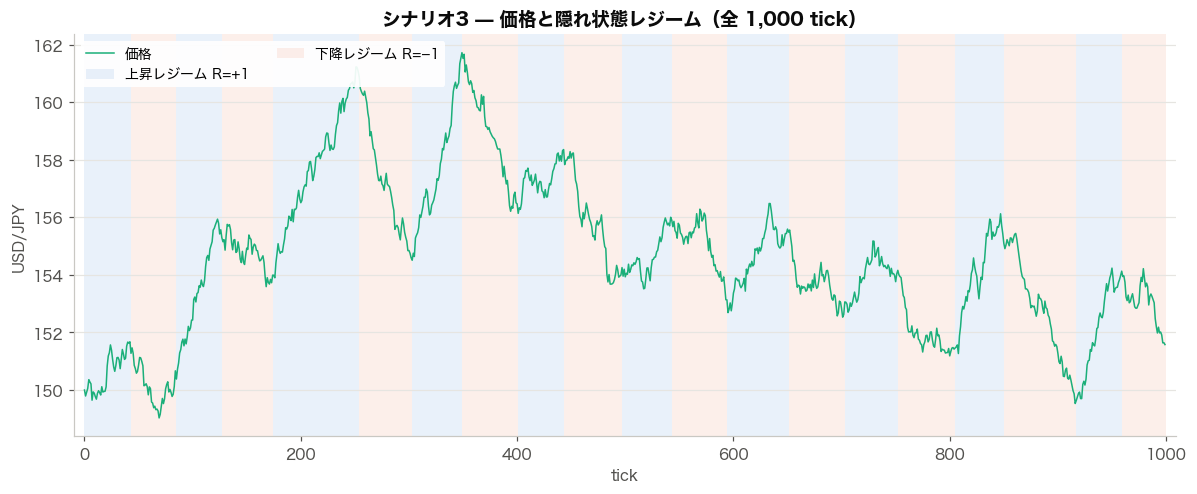

In [14]:
regime_plot(PRICES[3], REGIME3,
            "シナリオ3 — 価格と隠れ状態レジーム（全 1,000 tick）", n=SAMPLE_TICKS)

### なぜゴールデンクロスが効くのか

短期移動平均と長期移動平均を重ねると、**クロスがレジーム転換の少し後に起きている**ことが見えます。
この「少し後」がトレンド追従の宿命的な遅れ（ラグ）で、レジームが平均約51 tick 続くからこそ、
遅れて乗っても十分に取り返せます。

**長期線の窓がレジーム長を超えると成立しません。** 後のパラメータ感度表のとおり、
`long <= 30` は全て合格しますが `long >= 60`（平均レジーム長を超える）は全て落ちます。

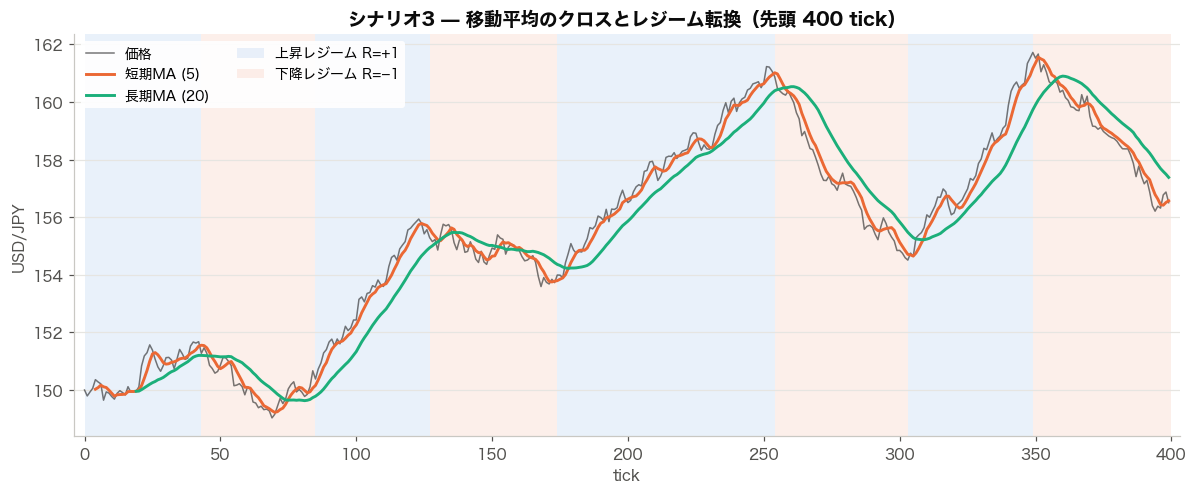

In [15]:
regime_plot(PRICES[3], REGIME3,
            "シナリオ3 — 移動平均のクロスとレジーム転換（先頭 400 tick）",
            n=400, mas=[(5, SERIES[1], "短期MA (5)"), (20, SERIES[2], "長期MA (20)")])

### レジーム反転ロジックの正確な挙動

コードは次のようになっています。

```python
hit = rng.rand() < p_switch            # ← 抽選は毎 tick 必ず行われる
if hit and run_len > min_regime_length:
    regime *= -1; run_len = 0
else:
    run_len += 1                       # ← 当選しても L<=40 ならこちら
```

**抽選は毎 tick 実行されます**（Python は `and` を左から評価するので `rng.rand()` は必ず消費される）。
ただし当選しても `run_len <= 40` なら反転は起きず、**その当選は繰り越されずに破棄されます**。
「40 になるまで待って当選を持ち越す」のではない点に注意してください。

この仕様の結果、**平均継続長は 10 tick になりません**。
最短 41 tick のロックアウトを終えてから毎 tick 1/10 の抽選になるので、
理論上の平均は `41 + 10 = 約51 tick` です。

1,000 tick 版では `min_regime_length` を長く（40）、抽選の平均待ちを短く（10）取っています。
**レジーム長のばらつきを小さく抑えるため**で、こうしないと上昇・下降レジームの総量が
偏って Buy & Hold が勝ってしまい、シナリオの設計が壊れます。

In [16]:
_edges = np.flatnonzero(np.diff(REGIME3)) + 1
_all = np.diff(np.r_[0, _edges, len(REGIME3)])
_complete, _censored = _all[:-1], _all[-1]   # 末尾は観測期間で打ち切られた区間

print(f"抽選回数        : {len(REGIME3) - 1:,}  (毎 tick 必ず1回)")
print(f"  うち破棄       : {WASTED3:,}  <- 当選したが run_len<=40 で無効化され、繰り越されない")
print(f"  実際の反転     : {len(_edges):,}")
print()
print(f"レジーム継続長（完結した {len(_complete)} 区間）:")
print(f"  平均 {_complete.mean():.1f} / 中央値 {np.median(_complete):.0f}"
      f" / 最短 {_complete.min()} / 最長 {_complete.max()} tick")
print(f"  理論値: 最低41 + 幾何分布(p=1/10)の平均10 = 約51 tick")
print(f"  ※ 末尾の {_censored} tick は観測打ち切りのため集計から除外")
print(f"  上昇レジーム比率: {(REGIME3 > 0).mean() * 100:.1f} %")

抽選回数        : 999  (毎 tick 必ず1回)
  うち破棄       : 80  <- 当選したが run_len<=40 で無効化され、繰り越されない
  実際の反転     : 19

レジーム継続長（完結した 19 区間）:
  平均 50.5 / 中央値 49 / 最短 42 / 最長 80 tick
  理論値: 最低41 + 幾何分布(p=1/10)の平均10 = 約51 tick
  ※ 末尾の 41 tick は観測打ち切りのため集計から除外
  上昇レジーム比率: 49.2 %


## 4.3 想定アルゴリズムと収益

### 想定解のアルゴリズム

```python
class GoldenCross(Strategy):
    """2本の移動平均の位置関係でレジームを推定する。"""

    def __init__(self, short_window=5, long_window=20):
        self.short_window, self.long_window = short_window, long_window

    def decide(self, t, prices):
        if len(prices) < self.long_window:
            return 0.0                        # 長期線が引けるまで待つ
        short_ma = prices[-self.short_window:].mean()
        long_ma  = prices[-self.long_window:].mean()
        return 1.0 if short_ma > long_ma else 0.0
```

1本の値動きではノイズに埋もれて向きが読めないので移動平均でならし、
**短期線が長期線を上抜けた**ことをもって「上昇レジームに入った」と推定します。

In [17]:
RESULTS[3] = {label: evaluate(s, PRICES[3]) for label, s, _ in BASE}

res = RESULTS[3]["ゴールデンクロス (5, 20)"]
print("想定解      : ゴールデンクロス (short=5, long=20)")
print(f"リターン    : {res['return_pct']:+.3f} %   （合格ライン {THRESHOLD[3]} %）")
print(f"最終資産    : {res['final']:,.0f} JPY")
print(f"最大DD      : {res['max_drawdown_pct']:.3f} %")

想定解      : ゴールデンクロス (short=5, long=20)
リターン    : +13.655 %   （合格ライン 5.0 %）
最終資産    : 1,136,547 JPY
最大DD      : -1.732 %


## 4.4 他のアルゴリズムでは届かない

**この節の内容は参加者には見せません。**

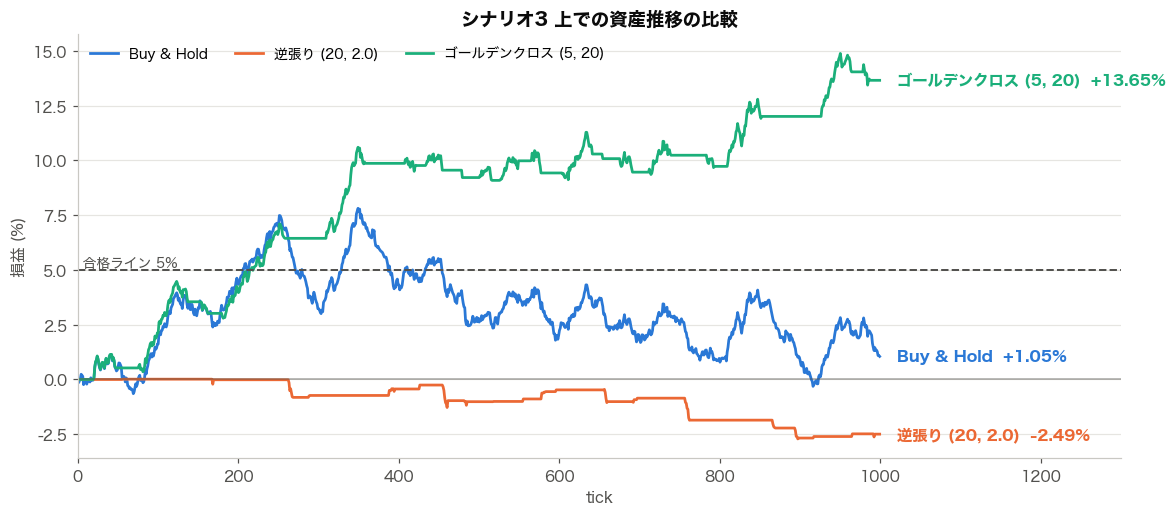

,試したパラメータ数,最良 [%],中央値 [%],最悪 [%],最良パラメータ,合格ライン(5.0%)超え
戦略ファミリー,,,,,,
Buy & Hold,1,1.053,1.053,1.053,Buy & Hold,0/1
逆張り (Bollinger),26,0.755,-0.712,-9.994,"逆張り (120, 2.0)",0/26
ゴールデンクロス,25,13.655,3.135,-9.509,"ゴールデンクロス (5, 20)",12/25


In [18]:
TABLES[3] = family_table(3)

equity_plot(3, [(label, RESULTS[3][label], color) for label, _, color in BASE])
display(TABLES[3])

### パラメータ感度（ゴールデンクロスのみ）

In [19]:
shorts, longs = [3, 5, 10, 20, 50], [15, 20, 30, 60, 100, 200]
grid3 = pd.DataFrame(
    [[round(evaluate(GoldenCross(s, l), PRICES[3])["return_pct"], 2) if s < l else np.nan
      for l in longs] for s in shorts],
    index=[f"short={s}" for s in shorts], columns=[f"long={l}" for l in longs],
)
th = THRESHOLD[3]
print(f"ゴールデンクロスのリターン [%]（太字＝合格ライン {th}% 超え / 空欄＝short>=long で無効）\n")
try:
    display(grid3.style.format("{:+.2f}", na_rep="—")
            .map(lambda v: "" if pd.isna(v) else
                 (f"color: {GOOD}; font-weight: bold" if v >= th else f"color: {BAD}"))
            .set_caption(f"シナリオ3 × ゴールデンクロス パラメータ感度（合格ライン {th}%）"))
except Exception:
    print(grid3.to_string())

vals = grid3.to_numpy()[~np.isnan(grid3.to_numpy())]
print(f"\n通過: {int((vals >= th).sum())}/{len(vals)} 通り")

ゴールデンクロスのリターン [%]（太字＝合格ライン 5.0% 超え / 空欄＝short>=long で無効）

          long=15  long=20  long=30  long=60  long=100  long=200
short=3     13.18    12.70    10.86     7.39      0.44     -3.69
short=5     13.19    13.65    10.97     6.15     -0.61     -4.03
short=10    11.49    12.94     9.68     3.14     -2.77     -5.75
short=20      NaN      NaN     5.36    -1.09     -5.85     -6.86
short=50      NaN      NaN      NaN    -9.51     -8.60     -6.59

通過: 12/25 通り


### 結論

- ゴールデンクロスは **12/25 通り**で合格ラインを超えます。
  通過するのは `long <= 30`（＝平均レジーム長 51 tick より短い窓）の全てで、
  最良は `short=5, long=20` の **13.66 %**。落ちるのは `long >= 60` の設定だけです。
- Buy & Hold は **+1.053 %**（上昇・下降レジームがほぼ相殺するため）、
  逆張りは全26通りで届かず、最良でも **0.76 %**。
- 合格ライン 5.0 % は、通過する12通りの最悪(5.36 %)のすぐ下、
  かつ他ファミリーの最良(1.05 %)を大きく上回る位置にあります。

---
# 5. 全体サマリ

## 5.1 戦略 × マーケット の収益行列

想定解のパラメータ（逆張り `20, 2.0` / ゴールデンクロス `20, 60`）で、
3つの戦略を3つのマーケットすべてに当てた結果です。

In [20]:
matrix = pd.DataFrame(
    [[RESULTS[n][label]["return_pct"] for n in (1, 2, 3)] for label, _, _ in BASE],
    index=[label for label, _, _ in BASE],
    columns=[f"シナリオ{n}\n{TITLE[n]}" for n in (1, 2, 3)],
).round(3)

print("行 = 戦略 / 列 = マーケット、セル = リターン(%)")
print("対角成分が各列の最大 = 「意図した戦略がそのデータで最も強い」\n")
try:
    display(matrix.style.format("{:+.3f}")
            .background_gradient(cmap="RdYlGn", axis=None)
            .set_caption("収益行列 [%]"))
except Exception:
    print(matrix.to_string())

diag_ok = all(matrix.iloc[i, i] == matrix.iloc[:, i].max() for i in range(3))
print(f"\n対角優位性: {'OK — 全列で対角成分が最大' if diag_ok else '要確認'}")

行 = 戦略 / 列 = マーケット、セル = リターン(%)
対角成分が各列の最大 = 「意図した戦略がそのデータで最も強い」

                  シナリオ1\nゆっくり育つマーケット  シナリオ2\n引き戻されるマーケット  シナリオ3\nトレンドが続くマーケット
Buy & Hold                     7.585              -0.733                1.053
逆張り (20, 2.0)                  0.277               8.549               -2.493
ゴールデンクロス (5, 20)               5.070             -25.445               13.655

対角優位性: OK — 全列で対角成分が最大


## 5.2 閾値の分離性能

各シナリオで **3つの戦略ファミリーをパラメータ総当たり**し、
合格ラインを超えられるのが意図した戦略ファミリーだけであることを確認します。

- Buy & Hold … パラメータなし（1通り）
- 逆張り … `window` × `num_std` のうち**実行可能な26通り**
  （30通り中4通りは後述のとおり構造的に発火不可能なので除外）
- ゴールデンクロス … `short` × `long` = 25通り

**合格ラインはシナリオ1のみ 7.0 %、シナリオ2・3 は 5.0 %** です。
43,200 tick 版では 3つとも 5.0 % で統一できましたが、1,000 tick ではシナリオ1で
ゴールデンクロスが 6.19 % まで伸びるため、統一すると分離が壊れます（シナリオ2.4節を参照）。

In [21]:
summary = []
for n in (1, 2, 3):
    tb, th = TABLES[n], THRESHOLD[n]
    row = {"シナリオ": f"{n}. {TITLE[n]}", "性質": NATURE[n],
           "合格ライン [%]": th, "想定解": INTENDED[n]}
    for fam in FAMILY:
        row[fam] = tb.loc[fam, f"合格ライン({th}%)超え"]
    summary.append(row)

summary_df = pd.DataFrame(summary).set_index("シナリオ")
print("各セル = 「合格ライン超えたパラメータ数 / 試した数」\n")
print(summary_df.to_string())

各セル = 「合格ライン超えたパラメータ数 / 試した数」

                                        性質  合格ライン [%]              想定解 Buy & Hold 逆張り (Bollinger) ゴールデンクロス
シナリオ                                                                                                      
1. ゆっくり育つマーケット               上に偏ったランダムウォーク        7.0       Buy & Hold        1/1            0/26     0/25
2. 引き戻されるマーケット   平均回帰 (Ornstein-Uhlenbeck)        5.0  逆張り (Bollinger)        0/1           15/26     0/25
3. トレンドが続くマーケット                 レジームスイッチング        5.0         ゴールデンクロス        0/1            0/26    12/25


### 読み方

意図した戦略ファミリーだけが合格ラインを超え、**他の2ファミリーは全パラメータで 0 通過**、
というのが設計どおりの状態です。上の表でそれが成立していることを確認してください。

これは「パラメータをいじって偶然通る」ことを防ぎます。参加者が閾値を超えたなら、
**その参加者は意図した考え方に到達している**と判断できます。

---
# 6. 運営向け補足

## 6.1 設計上の制約（API仕様から来るもの）

参加者向けノートブックは、実APIの仕様に合わせてあります。
ローカルシミュレータも**同じ制約**で動きます。

| 項目 | 仕様 | 由来 |
|---|---|---|
| ポジション | **0〜100 % のロングのみ**（売りは可 / **空売り**は不可） | `SessionService.next` が残高を `Math.max(…, 0)` で切る |
| 初期資金 | 1,000,000 JPY | `gameconfig.initialJpyAmount` |
| 手数料 | 0（`TEST1`〜`TEST4` のみ 0.1 %） | `GameConfig` |
| 約定 | その日のレートで約定 → 翌営業日へ | `SessionService.next` |

### 「空売り不可」であって「売り不可」ではありません

ここは誤解しやすいので明示しておきます。

- **できること** — 保有している USD を売って JPY に戻す（`currencyFrom: "USD"`）。
  比率 `1.0 → 0.0` はこの売り注文として約定します。**回数・金額に制限はありません。**
- **できないこと** — 保有していない USD を売り建てる（**空売り**）。
  負の比率を返しても、残高が `Math.max(…, 0)` で切られるため約定しません。

したがって取れるポジションは `[0, 1]` に限られ、**下向き判断時にできるのは
「売って現金化する（`0.0`）」までで、下落そのものから利益を取ることはできません。**

想定解が実際に出している注文数（1,000 tick、想定解パラメータ）:

| シナリオ / 想定解 | 買い注文 | 売り注文 | 売り総額 [JPY] |
|---|---:|---:|---:|
| 1. Buy & Hold | 1 | 0 | 0 |
| 2. 逆張り (20, 2.0) | 21 | 21 | 22,101,227 |
| 3. ゴールデンクロス (5, 20) | 21 | 21 | 22,840,947 |

シナリオ1の売りが 0 なのは Buy & Hold が定義上売らないからで、制約によるものではありません。
**本ノートブックの収益・合格ラインはすべてこの「売りあり・空売りなし」で算出しています。**

参考実装 `method.py` / `run_benchmark.py` は当初 `-1.0`（空売り）を返す実装でしたが、
API 仕様では約定しないため `[0, 1]` に修正済みです。

## 6.2 参加者がつまずきそうな箇所

| 箇所 | 想定されるつまずき | 用意してある手当て |
|---|---|---|
| Q1-1〜1-3 | `timeout` 未指定でセルが固まる | ヒントに明記 |
| Q1-3 | `data=` と `json=` の取り違え | ヒントと解答例コメントに明記 |
| Q1-4 | `state` の更新忘れで無限ループ | `max_steps` で `RuntimeError` |
| シナリオ1 | 「何もしない」が答えだと確信を持てない | 考察1〜4で段階的に誘導 |
| シナリオ2 | 全体図が帯にしか見えない | 拡大図のセルを併置 |
| シナリオ2 | `num_std` を大きくしすぎて未達 | 「20, 2.0 から試す」とヒント |
| 全般 | 履歴不足時（$t <$ window）の扱い | 各TODOに「返り値を決める」と明記 |

## 6.3 所要時間の目安

| Part | 目安 |
|---|---|
| Part 1（API接続） | 30〜45分 |
| 各シナリオ | 20〜40分 |
| Part 6（議論） | 15〜30分 |

計算時間は1シナリオあたり **1秒未満**（1,000 tick）。待ち時間は発生しません。

## 6.4 APIサーバについて（要対応）

- 共有サーバ `http://os3-389-27987.vs.sakura.ne.jp` は **応答しません**
  （TCP接続は成立するがHTTPが空応答。2026-07-30 時点）。
- ローカル起動も、リポジトリの現状では **そのままではビルドが通りません**。
  - `build.dependsOn(mithraGenerateSources)` は宣言されているが実行順序が保証されず、
    `compileJava` がコード生成より先に走って 137 件のコンパイルエラーになる。
  - `mithraGenerateSources` を単体実行しても
    `RejectedExecutionException: ThreadExecutor is already shutdown` で失敗する。
- **当日までにサーバ側の手当てが必要です。** 事前に動作環境を1つ用意し、
  参加者にはその `BASE_URL` を配るのが確実です。
- 参加者IDは **DB登録済みのものだけ**が有効（`TraderFinder` で引くため）。
  初期投入は `testuser` ほか。人数分の事前登録が必要です。

> **なお Part 2 以降（シナリオ1〜3）は API に一切依存しません。**
> 最悪サーバが間に合わなくても、演習の中核部分は実施できます。

## 6.5 配布時の作業

1. `day1-tutorial.ipynb` の各セルから `【解答例 / 講師用】` ブロックを削除
2. 末尾の付録セル（講師用メモ）を削除
3. `BASE_URL` を当日の環境に合わせて書き換え
4. **本ノートブック（`scenario_review.ipynb`）は配布しない**